## Linear Probes

### To Rule or Not To Rule

Running linear probes to see whether a rule representation is linerly decodable. Since in the language rules are mostly reflected by the grammar, we'll start there.

## Installation and Setup


In [ ]:
!pip install seaborn plotly transformer_lens
!pip uninstall -y torchaudio

  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of torch to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.0/821.0 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 84.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 101.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import json
import numpy as np
import torch
from google.colab import drive
from huggingface_hub import login
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from tqdm import tqdm
from transformer_lens import HookedTransformer

In [ ]:
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
!ls drive/MyDrive/Projects/PRISM/data

GrammarDiss_contexts.json	   GrammarDiss_dataset_variantC.json
GrammarDiss_dataset_variantA.json  GrammarDiss_rules.json
GrammarDiss_dataset_variantB.json


### Setup

In [ ]:
# HF login for Llamas
login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Running on 1B - the only model that fits into Colab's free tier

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = HookedTransformer.from_pretrained_no_processing(
    "meta-llama/Llama-3.2-1B-Instruct",
    device=device,
    torch_dtype=torch.float16,
)

n_layers = model.cfg.n_layers
d_model = model.cfg.d_model

config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Loaded pretrained model meta-llama/Llama-3.2-1B-Instruct into HookedTransformer


In [ ]:
FILE_PATH_A = "/content/drive/MyDrive/Projects/PRISM/data/GrammarDiss_dataset_variantA.json"
FILE_PATH_B = "/content/drive/MyDrive/Projects/PRISM/data/GrammarDiss_dataset_variantB.json"

**Dataset A:** Imperative=1 (DO smth) vs No grammar=0 (random words)

**Dataset B:** Modal obligation=1 (it MUST be done this way) vs Declarative past=0 (smth happened)

Each rule has a context to it which is usually neutral, e.g. "Is the weather nice today?"

In [ ]:
with open(FILE_PATH_A, "r", encoding="utf-8") as f:
    datasetA = json.load(f)

with open(FILE_PATH_B, "r", encoding="utf-8") as f:
    datasetB = json.load(f)

In [ ]:
train_listA = datasetA["train"]
test_listA = datasetA["test"]

train_listB = datasetB["train"]
test_listB = datasetB["test"]

In [ ]:
def extract_contrastive_features(samples):
  """Helper function to extract the activations."""
  contrastive_acts = np.zeros((len(samples), n_layers, d_model), dtype=np.float32)
  labels = np.zeros(len(samples), dtype=np.int32)

  for idx, sample in enumerate(samples):
      ctx_rule_text = sample["assembled_input"]
      ctx_only_text = sample["context"]
      labels[idx] = sample["label"]

      # Inference
      with torch.no_grad():
          _, cache_full = model.run_with_cache(ctx_rule_text, stop_at_layer=n_layers)
          _, cache_ctx = model.run_with_cache(ctx_only_text, stop_at_layer=n_layers)

      # Contrastive vector
      for layer in range(n_layers):
          hook_name = f"blocks.{layer}.hook_resid_post"

          act_full = cache_full[hook_name][0, -1, :].cpu().numpy()
          act_ctx = cache_ctx[hook_name][0, -1, :].cpu().numpy()
          # subtracting context vectors from the context+rule vector
          # that should give a representation of a rule
          contrastive_acts[idx, layer, :] = act_full - act_ctx

      del cache_full, cache_ctx
      torch.cuda.empty_cache()

  return contrastive_acts, labels

In [ ]:
X_train_all_A, y_train_A = extract_contrastive_features(train_listA)
X_test_all_A, y_test_A = extract_contrastive_features(test_listA)

In [ ]:
X_train_all_B, y_train_B = extract_contrastive_features(train_listB)
X_test_all_B, y_test_B = extract_contrastive_features(test_listB)

In [ ]:
X_train_all_A.shape, X_train_all_B.shape

((200, 16, 2048), (200, 16, 2048))

In [ ]:
layer_accs = []
layer_accsB = []

## Training a Probe

Training a simple linear probe from *scikit-learn*. Starting with *LogisicRegression*. It is simple enough to detect whether a rule feature is linearly decodable

### Dataset A

In [ ]:
for layer in range(n_layers):
    # extract the layer slice
    X_train_layer_A = X_train_all_A[:, layer, :]
    X_test_layer_A = X_test_all_A[:, layer, :]

    # training
    probe = LogisticRegression(max_iter=1000)
    probe.fit(X_train_layer_A, y_train_A)

    train_acc = accuracy_score(y_train_A, probe.predict(X_train_layer_A))
    test_preds_A = probe.predict(X_test_layer_A)
    test_acc = accuracy_score(y_test_A, test_preds_A)

    print(f"{layer}")
    print(f"Train: {train_acc}, Test: {test_acc:<22.4f}")
    print(
        classification_report(
            y_test_A,
            test_preds_A,
            target_names=["No Grammar (0)", "Imperative (1)"],
            zero_division=0
        )
    )
    print('################################################')
    layer_accs.append({'layer': layer, 'train_acc': train_acc, 'test_acc': test_acc})

0
Train: 0.99, Test: 0.5000                
                precision    recall  f1-score   support

No Grammar (0)       0.00      0.00      0.00        50
Imperative (1)       0.50      1.00      0.67        50

      accuracy                           0.50       100
     macro avg       0.25      0.50      0.33       100
  weighted avg       0.25      0.50      0.33       100

################################################
1
Train: 1.0, Test: 0.5000                
                precision    recall  f1-score   support

No Grammar (0)       0.00      0.00      0.00        50
Imperative (1)       0.50      1.00      0.67        50

      accuracy                           0.50       100
     macro avg       0.25      0.50      0.33       100
  weighted avg       0.25      0.50      0.33       100

################################################
2
Train: 1.0, Test: 0.5000                
                precision    recall  f1-score   support

No Grammar (0)       0.00      0.00  

### Dataset B

In [ ]:
for layer in range(n_layers):
    # extract the layer slice
    X_train_layer_B = X_train_all_B[:, layer, :]
    X_test_layer_B = X_test_all_B[:, layer, :]

    # training
    probe = LogisticRegression(max_iter=1000)
    probe.fit(X_train_layer_B, y_train_B)

    train_acc = accuracy_score(y_train_B, probe.predict(X_train_layer_B))
    test_preds_B = probe.predict(X_test_layer_B)
    test_acc = accuracy_score(y_test_B, test_preds_B)

    print(f"{layer}")
    print(f"Train: {train_acc}, Test: {test_acc:<22.4f}")
    print(
        classification_report(
            y_test_B,
            test_preds_B,
            target_names=["Declarative Past (0)", "Modal Obligation (1)"],
            zero_division=0
        )
    )
    print('################################################')
    layer_accsB.append({'layer': layer, 'train_acc': train_acc, 'test_acc': test_acc})

0
Train: 0.99, Test: 0.3800                
                      precision    recall  f1-score   support

Declarative Past (0)       0.00      0.00      0.00        50
Modal Obligation (1)       0.43      0.76      0.55        50

            accuracy                           0.38       100
           macro avg       0.22      0.38      0.28       100
        weighted avg       0.22      0.38      0.28       100

################################################
1
Train: 0.995, Test: 0.5800                
                      precision    recall  f1-score   support

Declarative Past (0)       0.90      0.18      0.30        50
Modal Obligation (1)       0.54      0.98      0.70        50

            accuracy                           0.58       100
           macro avg       0.72      0.58      0.50       100
        weighted avg       0.72      0.58      0.50       100

################################################
2
Train: 1.0, Test: 0.6600                
                    

The previous rules from both data subsets were very language-heavy.

To make sure, this subset does not have lang-related rules at all.

The design of the dataset is similar to A and B

In [ ]:
FILE_PATH_C = "/content/drive/MyDrive/Projects/PRISM/data/GrammarDiss_dataset_variantC.json"

In [ ]:
with open(FILE_PATH_C, "r", encoding="utf-8") as f:
    datasetC = json.load(f)

In [ ]:
train_listC = datasetC["train"]
test_listC = datasetC["test"]

In [ ]:
X_train_all_C, y_train_C = extract_contrastive_features(train_listC)
X_test_all_C, y_test_C = extract_contrastive_features(test_listC)

In [ ]:
layer_accsC = []

In [ ]:
for layer in range(n_layers):
    # extract the layer slice
    X_train_layer_C = X_train_all_C[:, layer, :]
    X_test_layer_C = X_test_all_C[:, layer, :]

    # training
    probe = LogisticRegression(max_iter=1000)
    probe.fit(X_train_layer_C, y_train_C)

    train_acc = accuracy_score(y_train_C, probe.predict(X_train_layer_C))
    test_preds_C = probe.predict(X_test_layer_C)
    test_acc = accuracy_score(y_test_C, test_preds_C)

    print(f"{layer}")
    print(f"Train: {train_acc}, Test: {test_acc:<22.4f}")
    print(
        classification_report(
            y_test_C,
            test_preds_C,
            target_names=["Declarative Past (0)", "Imperative (1)"],
            zero_division=0
        )
    )
    print('################################################')
    layer_accsC.append({'layer': layer, 'train_acc': train_acc, 'test_acc': test_acc})

0
Train: 0.95, Test: 0.9700                
                      precision    recall  f1-score   support

Declarative Past (0)       0.96      0.98      0.97        50
Modal Obligation (1)       0.98      0.96      0.97        50

            accuracy                           0.97       100
           macro avg       0.97      0.97      0.97       100
        weighted avg       0.97      0.97      0.97       100

################################################
1
Train: 1.0, Test: 1.0000                
                      precision    recall  f1-score   support

Declarative Past (0)       1.00      1.00      1.00        50
Modal Obligation (1)       1.00      1.00      1.00        50

            accuracy                           1.00       100
           macro avg       1.00      1.00      1.00       100
        weighted avg       1.00      1.00      1.00       100

################################################
2
Train: 1.0, Test: 1.0000                
                      

### Computing and visualising recall per label

In [ ]:
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt

recall_label0_A = []
recall_label1_A = []

# Recalculate per-label accuracy for Dataset A
for layer in range(n_layers):
    X_train_layer_A = X_train_all_A[:, layer, :]
    X_test_layer_A = X_test_all_A[:, layer, :]

    probe = LogisticRegression(max_iter=1000)
    probe.fit(X_train_layer_A, y_train_A)

    test_preds_A = probe.predict(X_test_layer_A)

    # Get precision, recall, fscore, support for each class
    metrics = precision_recall_fscore_support(y_test_A, test_preds_A, average=None, zero_division=0)

    recall_label0_A.append(metrics[1][0]) # Recall for label 0
    recall_label1_A.append(metrics[1][1]) # Recall for label 1

recall_label0_B = []
recall_label1_B = []

# Recalculate per-label accuracy for Dataset B
for layer in range(n_layers):
    X_train_layer_B = X_train_all_B[:, layer, :]
    X_test_layer_B = X_test_all_B[:, layer, :]

    probe = LogisticRegression(max_iter=1000)
    probe.fit(X_train_layer_B, y_train_B)

    test_preds_B = probe.predict(X_test_layer_B)

    # Get precision, recall, fscore, support for each class
    metrics = precision_recall_fscore_support(y_test_B, test_preds_B, average=None, zero_division=0)

    recall_label0_B.append(metrics[1][0]) # Recall for label 0
    recall_label1_B.append(metrics[1][1]) # Recall for label 1

recall_label0_C = []
recall_label1_C = []

# Recalculate per-label accuracy for Dataset B
for layer in range(n_layers):
    X_train_layer_C = X_train_all_C[:, layer, :]
    X_test_layer_C = X_test_all_C[:, layer, :]

    probe = LogisticRegression(max_iter=1000)
    probe.fit(X_train_layer_C, y_train_C)

    test_preds_C = probe.predict(X_test_layer_C)

    # Get precision, recall, fscore, support for each class
    metrics = precision_recall_fscore_support(y_test_C, test_preds_C, average=None, zero_division=0)

    recall_label0_C.append(metrics[1][0]) # Recall for label 0
    recall_label1_C.append(metrics[1][1]) # Recall for label 1


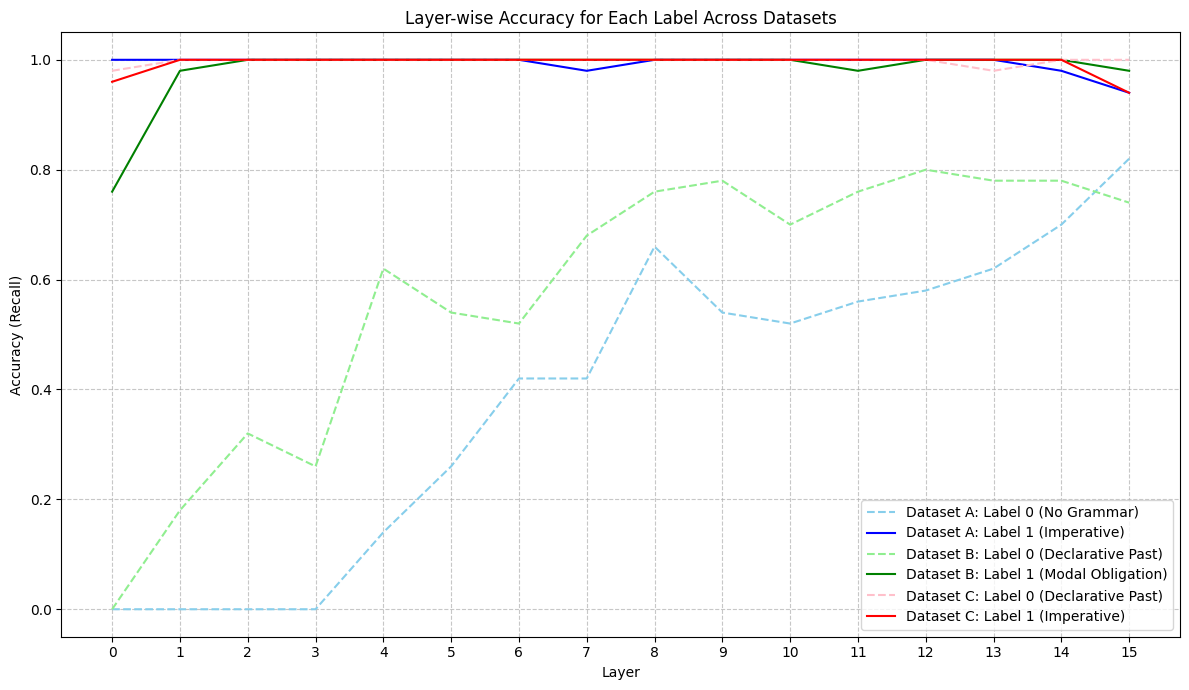

In [ ]:
layers = range(n_layers)

plt.figure(figsize=(12, 7))

# Plot Dataset A
plt.plot(layers, recall_label0_A, linestyle='--', color='skyblue', label='Dataset A: Label 0 (No Grammar)')
plt.plot(layers, recall_label1_A, linestyle='-', color='blue', label='Dataset A: Label 1 (Imperative)')

# Plot Dataset B
plt.plot(layers, recall_label0_B, linestyle='--', color='lightgreen', label='Dataset B: Label 0 (Declarative Past)')
plt.plot(layers, recall_label1_B, linestyle='-', color='green', label='Dataset B: Label 1 (Modal Obligation)')

# Plot Dataset C
plt.plot(layers, recall_label0_C, linestyle='--', color='pink', label='Dataset C: Label 0 (Declarative Past)')
plt.plot(layers, recall_label1_C, linestyle='-', color='red', label='Dataset C: Label 1 (Imperative)')

plt.xlabel('Layer')
plt.ylabel('Accuracy (Recall)')
plt.title('Layer-wise Accuracy for Each Label Across Datasets')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(layers)
plt.ylim(-0.05, 1.05) # Set y-axis limits to clearly show 0 to 1 accuracy
plt.tight_layout()
plt.show()

The results have a pretty high accuracy. And attribution to label 1 is likely happening due to the formula of the loss function.

What's more important is that the distinction between the classes on A and B starts emerging in, presumably syntactic layers (4-12) and by the layer 13, rule vs non-rule is a pretty well crystalised concept which gets even stronger.

My open points are:

* The slight drop in accuracy in the latest layers is within the noise range. But what if it indicates transiency in larger models? -> check non-linear classifiers for that
* The probes show that "to rule or not to rule" is **linearly decodable**. But it does not necessarily confirm its linearity as representation

